<a href="https://colab.research.google.com/github/muhardan/Tugas-Praktikum-1-AI/blob/main/linear_regresion_tugas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics

In [2]:
# 1. BUAT DATA SENDIRI: Prediksi Harga Mobil Bekas
data = {
    'umur_mobil_thn': [1, 2, 3, 5, 5, 7, 8, 10, 12, 15],
    'jarak_tempuh_ribu_km': [10, 25, 40, 60, 80, 100, 120, 150, 180, 200],
    'kapasitas_mesin_cc': [1000, 1200, 1500, 1000, 1500, 1200, 2000, 1500, 1000, 2000],
    'harga_juta': [180, 160, 150, 120, 130, 110, 100, 85, 60, 50]
}

df = pd.DataFrame(data)
print("--- Data Mobil Bekas ---")
print(df)
print("\n")

--- Data Mobil Bekas ---
   umur_mobil_thn  jarak_tempuh_ribu_km  kapasitas_mesin_cc  harga_juta
0               1                    10                1000         180
1               2                    25                1200         160
2               3                    40                1500         150
3               5                    60                1000         120
4               5                    80                1500         130
5               7                   100                1200         110
6               8                   120                2000         100
7              10                   150                1500          85
8              12                   180                1000          60
9              15                   200                2000          50




In [3]:
# menentukan variabel
X = df[['umur_mobil_thn', 'jarak_tempuh_ribu_km', 'kapasitas_mesin_cc']]
y = df['harga_juta']

In [4]:
# split data train dan test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# membuat model regresi
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [6]:
# melihat atau menghitung koefisien
print("Intercept (a):", model.intercept_)
print("Koefisien (b1, b2, b3):", model.coef_)
# b1 → pengaruh umur mobil
# b2 → pengaruh jarak tempuh
# b3 → pengaruh kapasitas mesin

Intercept (a): 169.20035629112448
Koefisien (b1, b2, b3): [-5.50822794 -0.27725032  0.00679929]


In [7]:
# prediksi data testing
y_pred = model.predict(X_test)

print("\n--- Hasil Prediksi ---")
print("Prediksi:", y_pred)
print("Harga Asli:", y_test.values)


--- Hasil Prediksi ---
Prediksi: [ 59.99585422 159.41179127]
Harga Asli: [ 60 160]


In [8]:
# evaluasi model
print("\n--- Evaluasi Model ---")
print("MAE:", metrics.mean_absolute_error(y_test, y_pred))
print("MSE:", metrics.mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(metrics.mean_squared_error(y_test, y_pred)))


--- Evaluasi Model ---
MAE: 0.29617725893895397
MSE: 0.1730033511729559
RMSE: 0.41593671534616405


In [9]:
# prediksi data baru
data_baru = [[4, 50, 1500]] # Umur 4 thn, 50rb KM, 1500cc
prediksi = model.predict(data_baru)
print(f"\nPrediksi harga mobil (Umur 4thn, 50k KM, 1500cc): {prediksi[0]:.2f} Juta")


Prediksi harga mobil (Umur 4thn, 50k KM, 1500cc): 143.50 Juta


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [10]:
# ANALISIS
print("\n=======================================================")
print("ANALISIS REGRESI LINEAR BERGANDA:")
print("1. Koefisien b1 (umur) dan b2 (jarak tempuh) bernilai negatif, artinya semakin tua dan jauh jarak tempuhnya, harga mobil makin turun.")
print("2. Koefisien b3 (kapasitas mesin) bernilai positif, menunjukkan bahwa CC mesin yang lebih besar cenderung menaikkan harga jual mobil.")
print("3. Analisis ini sangat logis dan sesuai dengan realita pasar otomotif saat ini.")
print("=======================================================")


ANALISIS REGRESI LINEAR BERGANDA:
1. Koefisien b1 (umur) dan b2 (jarak tempuh) bernilai negatif, artinya semakin tua dan jauh jarak tempuhnya, harga mobil makin turun.
2. Koefisien b3 (kapasitas mesin) bernilai positif, menunjukkan bahwa CC mesin yang lebih besar cenderung menaikkan harga jual mobil.
3. Analisis ini sangat logis dan sesuai dengan realita pasar otomotif saat ini.


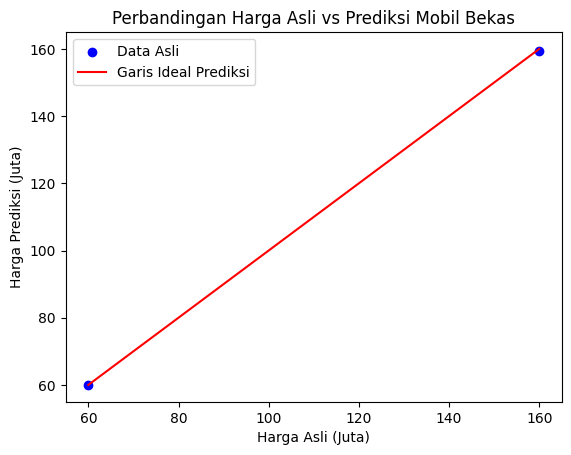

In [11]:
# tampil visualisasi
plt.scatter(y_test, y_pred, color = 'blue', label='Data Asli')
plt.plot(y_test, y_test, color='red', label='Garis Ideal Prediksi')
plt.xlabel("Harga Asli (Juta)")
plt.ylabel("Harga Prediksi (Juta)")
plt.title("Perbandingan Harga Asli vs Prediksi Mobil Bekas")
plt.legend()
plt.show()